# Bayesian Updating with Sequential Data: Email Arrival Rates

This notebook demonstrates sequential Bayesian updating for estimating the rate parameter (λ) of a Poisson distribution, given a Gamma prior. We'll simulate email arrivals over several hours and update our belief about the average hourly email rate using each new observation. We will also compare the Bayesian approach with raw empirical rates and Laplace-smoothed rates.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import gamma
import scipy.integrate as integrate

In [ ]:
# ============================================================
# Initial Gamma prior
# ============================================================

# Prior belief:
# approximately 3 emails per hour

alpha_prior = 3
beta_prior = 1

# Gamma distribution uses scale = 1 / rate
prior = lambda lam: gamma.pdf(
    lam,
    a=alpha_prior,
    scale=1 / beta_prior
)

# Range of possible hourly email rates
x = np.linspace(0, 12, 1000)

# Prior mean
prior_mean = alpha_prior / beta_prior

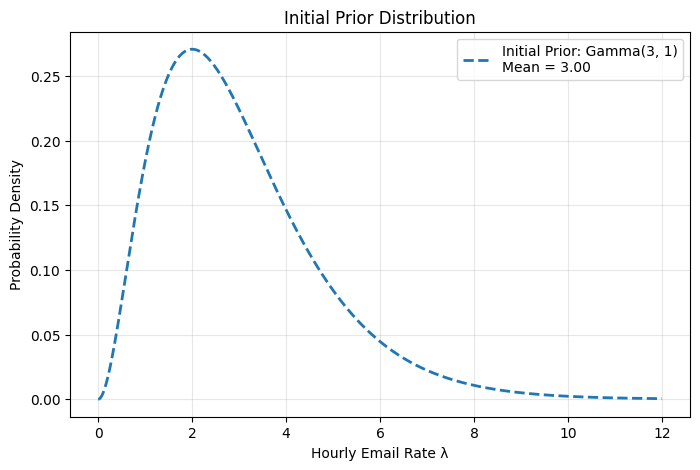

In [ ]:
# ============================================================
# Initial prior distribution
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    x,
    prior(x),
    linestyle="dashed",
    linewidth=2,
    label=(
        f"Initial Prior: Gamma({alpha_prior}, {beta_prior})\n"
        f"Mean = {prior_mean:.2f}"
    )
)

plt.xlabel("Hourly Email Rate λ")
plt.ylabel("Probability Density")
plt.title("Initial Prior Distribution")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# ============================================================
# Sequential observations
# ============================================================

# Number of emails received during each hour.
#
# Zero-email hours are deliberately included.

observations = np.array([
    0,
    3,
    4,
    0,
    2,
    5,
    0,
    3
])

In [ ]:
# ============================================================
# Sequential Bayesian update function
# ============================================================

def update_prob(prior, observation):
    """
    Perform one Bayesian update using one Poisson observation.

    observation = number of emails observed in one hour
    """

    # --------------------------------------------------------
    # Poisson likelihood
    #
    # P(Y = y | lambda) is proportional to:
    #
    # lambda^y * exp(-lambda)
    #
    # The factorial term y! does not depend on lambda and
    # therefore cancels when the posterior is normalized.
    # --------------------------------------------------------

    likelihood = lambda lam: (
        lam ** observation
        * np.exp(-lam)
    )

    # --------------------------------------------------------
    # Unnormalized posterior
    # --------------------------------------------------------

    posterior_unnorm = lambda lam: (
        prior(lam) * likelihood(lam)
    )

    # --------------------------------------------------------
    # Normalizing constant
    # --------------------------------------------------------

    evidence = integrate.quad(
        posterior_unnorm,
        0,
        np.inf
    )[0]

    # --------------------------------------------------------
    # Normalized posterior
    # --------------------------------------------------------

    posterior = lambda lam: (
        posterior_unnorm(lam) / evidence
    )

    return posterior

In [ ]:
# ============================================================
# Sequential Bayesian updating
# ============================================================

# Store the initial prior
posteriors = [prior]

# Current probability distribution
current_prob = prior

# Update one hour at a time
for observation in observations:

    # New observation updates the current distribution
    current_prob = update_prob(
        current_prob,
        observation
    )

    # The new posterior becomes the prior for the next hour
    posteriors.append(current_prob)

## Visualizing Sequential Posterior Distributions

Now, let's visualize how our probability distribution for the hourly email rate (λ) changes with each new observation. Each line represents the posterior distribution after a specific hour's observation, which then becomes the prior for the next hour.

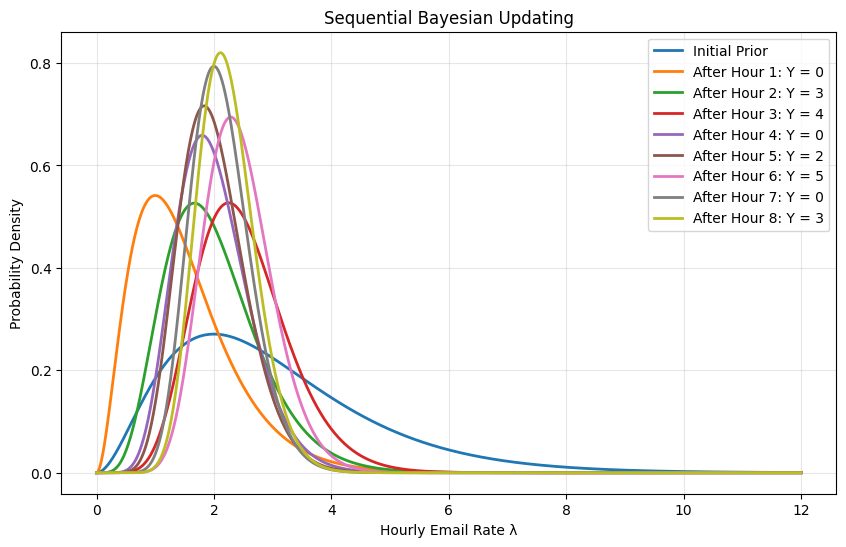

In [ ]:
# ============================================================
# Plot sequential distributions
# ============================================================

plt.figure(figsize=(10, 6))

for i, posterior_i in enumerate(posteriors):

    if i == 0:
        label = "Initial Prior"
    else:
        label = f"After Hour {i}: Y = {observations[i-1]}"

    plt.plot(
        x,
        [posterior_i(lam) for lam in x],
        linewidth=2,
        label=label
    )

plt.xlabel("Hourly Email Rate λ")
plt.ylabel("Probability Density")
plt.title("Sequential Bayesian Updating")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Tracking Gamma Parameters Analytically

Since the Gamma distribution is the conjugate prior for the Poisson likelihood, we can update its parameters (alpha and beta) analytically. After each observation, the new posterior parameters are simply calculated by adding the observation to `alpha_current` and adding 1 to `beta_current`.

In [ ]:
# ============================================================
# Track Gamma parameters after each hour
# ============================================================

alpha_values = [alpha_prior]
beta_values = [beta_prior]

alpha_current = alpha_prior
beta_current = beta_prior

for observation in observations:

    alpha_current += observation
    beta_current += 1

    alpha_values.append(alpha_current)
    beta_values.append(beta_current)

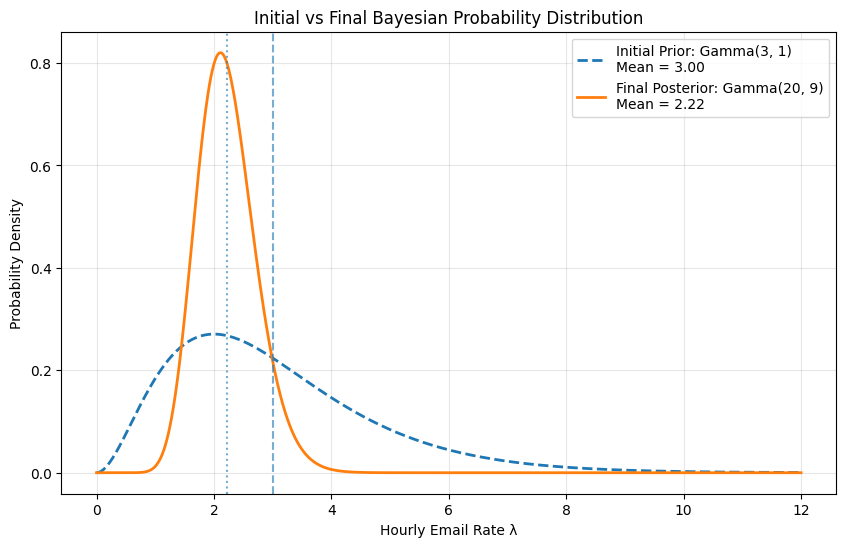

In [ ]:
# ============================================================
# Initial vs Final Distribution
# ============================================================

initial_prob = posteriors[0]
final_prob = posteriors[-1]

# Final posterior parameters
alpha_post = alpha_values[-1]
beta_post = beta_values[-1]

# Means
initial_mean = alpha_prior / beta_prior
final_mean = alpha_post / beta_post

# Evaluate densities
initial_density = np.array([
    initial_prob(lam) for lam in x
])

final_density = np.array([
    final_prob(lam) for lam in x
])

plt.figure(figsize=(10, 6))

plt.plot(
    x,
    initial_density,
    linestyle="dashed",
    linewidth=2,
    label=(
        f"Initial Prior: Gamma({alpha_prior}, {beta_prior})\n"
        f"Mean = {initial_mean:.2f}"
    )
)

plt.plot(
    x,
    final_density,
    linewidth=2,
    label=(
        f"Final Posterior: Gamma({alpha_post}, {beta_post})\n"
        f"Mean = {final_mean:.2f}"
    )
)

plt.axvline(
    initial_mean,
    linestyle="dashed",
    alpha=0.6
)

plt.axvline(
    final_mean,
    linestyle="dotted",
    alpha=0.6
)

plt.xlabel("Hourly Email Rate λ")
plt.ylabel("Probability Density")
plt.title("Initial vs Final Bayesian Probability Distribution")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Comparing with Empirical and Laplace-Smoothed Rates

Beyond Bayesian updating, it's also insightful to compare the results with frequentist estimates like the raw empirical rate and the Laplace-smoothed rate (add-one smoothing). This section calculates and visualizes these alternative estimates alongside the Bayesian approach.

In [ ]:
# ============================================================
# Sequential raw and Laplace-smoothed rates
# ============================================================

raw_rates = []
laplace_rates = []

cumulative_emails = 0

for hour, observation in enumerate(observations, start=1):

    cumulative_emails += observation

    # Raw empirical rate
    raw_rate = cumulative_emails / hour

    # Laplace/add-one smoothed rate
    laplace_rate = (
        cumulative_emails + 1
    ) / (
        hour + 1
    )

    raw_rates.append(raw_rate)
    laplace_rates.append(laplace_rate)

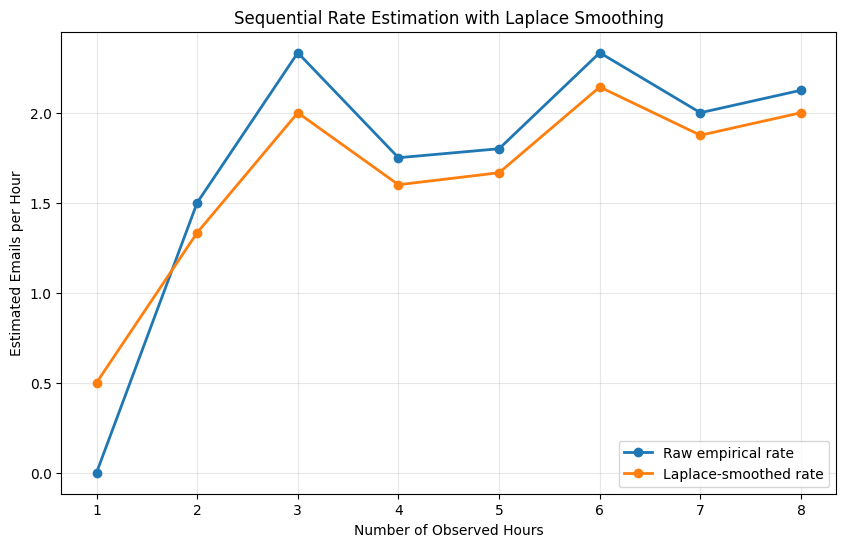

In [ ]:
# ============================================================
# Plot raw and smoothed estimates
# ============================================================

hours = np.arange(
    1,
    len(observations) + 1
)

plt.figure(figsize=(10, 6))

plt.plot(
    hours,
    raw_rates,
    marker="o",
    linewidth=2,
    label="Raw empirical rate"
)

plt.plot(
    hours,
    laplace_rates,
    marker="o",
    linewidth=2,
    label="Laplace-smoothed rate"
)

plt.xlabel("Number of Observed Hours")
plt.ylabel("Estimated Emails per Hour")
plt.title("Sequential Rate Estimation with Laplace Smoothing")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# ============================================================
# Final estimates
# ============================================================

total_emails = np.sum(observations)
total_hours = len(observations)

raw_rate_final = total_emails / total_hours

laplace_rate_final = (
    total_emails + 1
) / (
    total_hours + 1
)

bayesian_rate_final = (
    alpha_post / beta_post
)

print("Final estimates")
print("-----------------------------")
print(f"Total hours:              {total_hours}")
print(f"Total emails:             {total_emails}")
print(f"Raw empirical rate:       {raw_rate_final:.3f}")
print(f"Laplace-smoothed rate:    {laplace_rate_final:.3f}")
print(f"Bayesian posterior mean:  {bayesian_rate_final:.3f}")

Final estimates
-----------------------------
Total hours:              8
Total emails:             17
Raw empirical rate:       2.125
Laplace-smoothed rate:    2.000
Bayesian posterior mean:  2.222


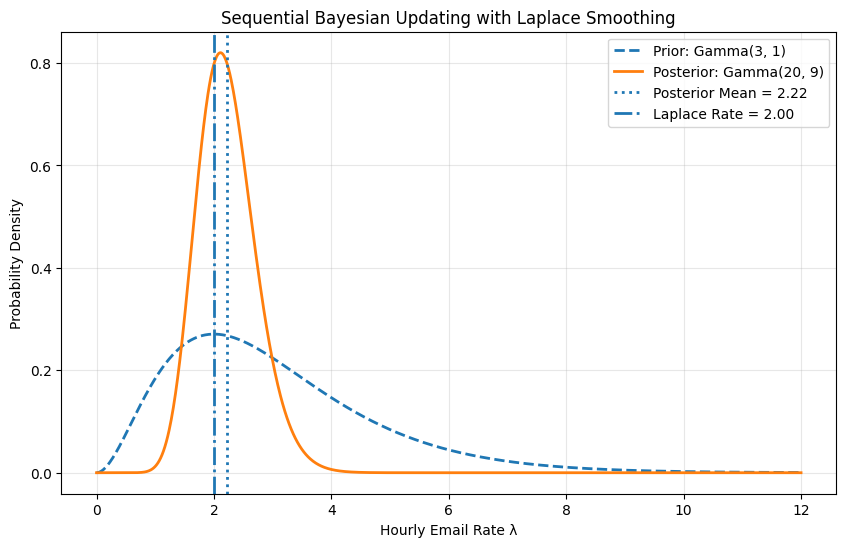

In [ ]:
# ============================================================
# Final combined visualization
# ============================================================

plt.figure(figsize=(10, 6))

# Initial prior
plt.plot(
    x,
    initial_density,
    linestyle="dashed",
    linewidth=2,
    label=(
        f"Prior: Gamma({alpha_prior}, {beta_prior})"
    )
)

# Final posterior
plt.plot(
    x,
    final_density,
    linewidth=2,
    label=(
        f"Posterior: Gamma({alpha_post}, {beta_post})"
    )
)

# Bayesian posterior mean
plt.axvline(
    bayesian_rate_final,
    linestyle="dotted",
    linewidth=2,
    label=f"Posterior Mean = {bayesian_rate_final:.2f}"
)

# Laplace estimate
plt.axvline(
    laplace_rate_final,
    linestyle="dashdot",
    linewidth=2,
    label=f"Laplace Rate = {laplace_rate_final:.2f}"
)

plt.xlabel("Hourly Email Rate λ")
plt.ylabel("Probability Density")
plt.title("Sequential Bayesian Updating with Laplace Smoothing")

plt.legend()
plt.grid(alpha=0.3)

plt.show()